In [106]:
import pandas as pd
import sqlite3


In [107]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [108]:
test_query = "SELECT pageviews.datetime FROM pageviews WHERE pageviews.uid NOT LIKE 'admin%' LIMIT 10;"

pageviews_10 = pd.read_sql(test_query, conn)
pageviews_10

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
5,2020-04-18 12:06:13.237290
6,2020-04-18 12:06:35.574114
7,2020-04-18 12:19:50.182714
8,2020-04-18 18:14:53.813657
9,2020-04-18 18:20:05.419381


In [109]:
query = """
SELECT datetime 
FROM pageviews 
WHERE pageviews.uid NOT LIKE 'admin%'
"""
df = pd.read_sql(query, conn)

df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
views_per_day = df.groupby('date').size().reset_index(name='views')

views_per_day

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


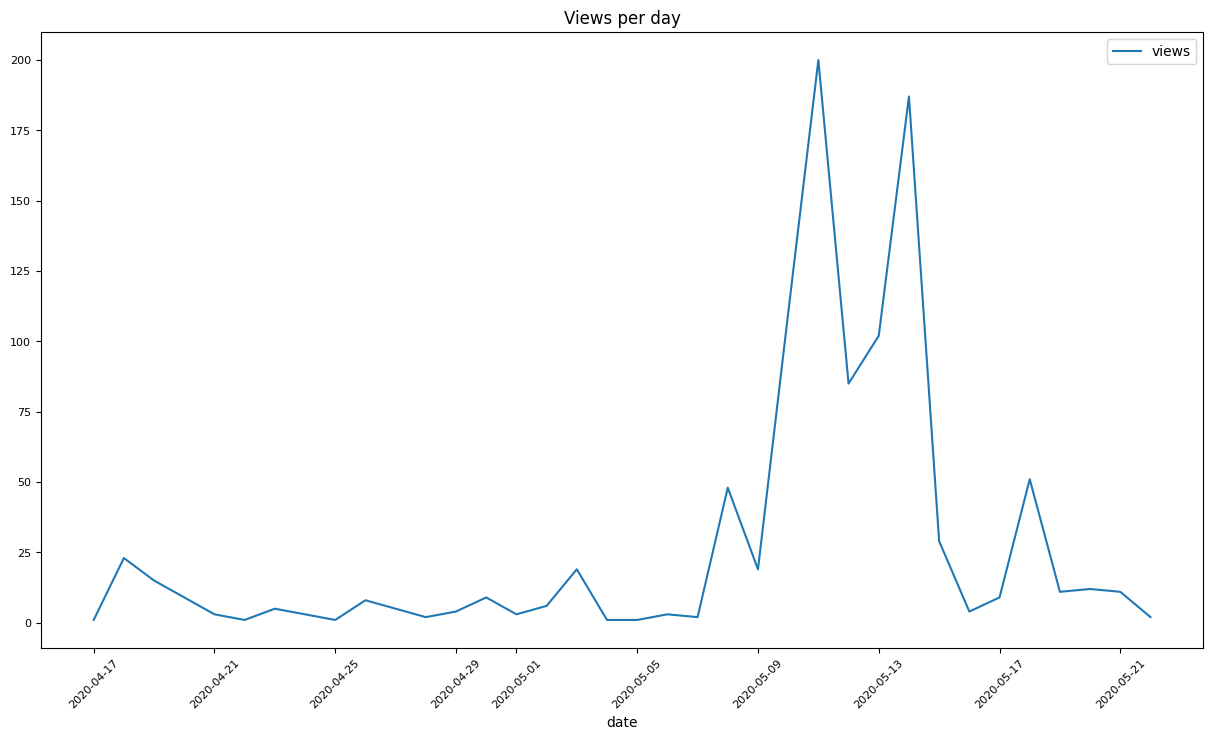

In [110]:
plot = views_per_day.plot(x='date', y='views', kind='line', title='Views per day', figsize=(15, 8), fontsize=8, rot=45)

In [111]:
conn.close()